In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [3]:
hourly_df = pd.read_csv(
    "../../data/processed/hourly_device_energy.csv",
    parse_dates=["timestamp"]
)

hourly_df = hourly_df.set_index("timestamp")
hourly_df.head()


,Appliance Type,Energy Consumption (kWh)
timestamp,,
2023-01-01 00:00:00,Air Conditioning,4.42
2023-01-01 01:00:00,Air Conditioning,7.61
2023-01-01 02:00:00,Air Conditioning,14.80
2023-01-01 03:00:00,Air Conditioning,4.19
2023-01-01 04:00:00,Air Conditioning,10.68


In [4]:
# Detect unique appliances
appliances = hourly_df["Appliance Type"].unique()
print(f"Detected appliances: {appliances}")


Detected appliances: ['Air Conditioning' 'Computer' 'Dishwasher' 'Fridge' 'Heater' 'Lights'
 'Microwave' 'Oven' 'TV' 'Washing Machine']


In [8]:
# --- Feature Engineering (REQUIRED before modeling) ---

hourly_df["hour"] = hourly_df.index.hour
hourly_df["day"] = hourly_df.index.day
hourly_df["weekday"] = hourly_df.index.weekday
hourly_df["month"] = hourly_df.index.month

hourly_df["lag_1"] = hourly_df["Energy Consumption (kWh)"].shift(1)
hourly_df["lag_24"] = hourly_df["Energy Consumption (kWh)"].shift(24)

hourly_df["rolling_mean_24"] = (
    hourly_df["Energy Consumption (kWh)"]
    .rolling(window=24)
    .mean()
)

hourly_df = hourly_df.dropna()


In [9]:
hourly_df.columns


Index(['Appliance Type', 'Energy Consumption (kWh)', 'hour', 'day', 'weekday',
       'month', 'lag_1', 'lag_24', 'rolling_mean_24'],
      dtype='object')

In [4]:
FEATURE_COLUMNS = [
    "hour",
    "day",
    "weekday",
    "month",
    "lag_1",
    "lag_24",
    "rolling_mean_24"
]


In [5]:
appliances = hourly_df["Appliance Type"].unique()

results = []
models = {}


In [11]:
import os

os.makedirs("../models", exist_ok=True)



Training model for: Air Conditioning


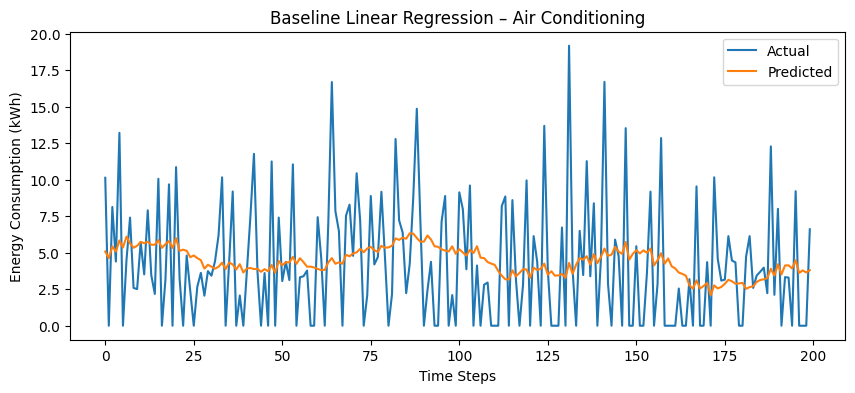


Training model for: Computer


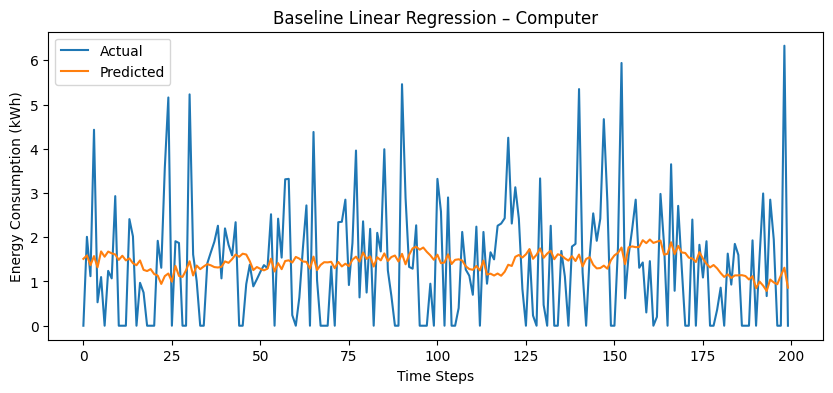


Training model for: Dishwasher


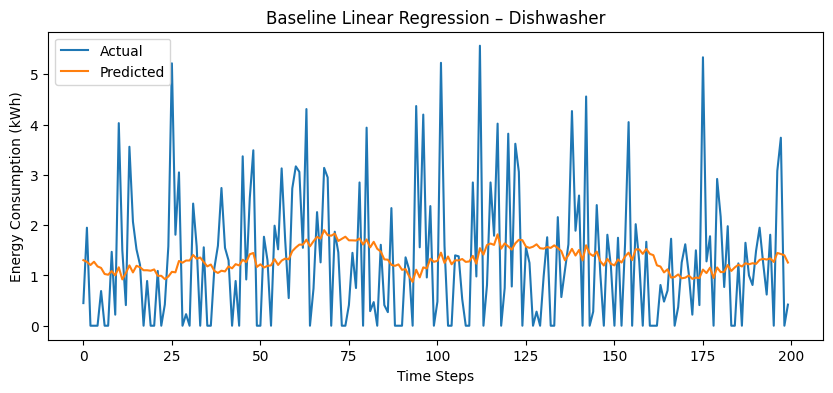


Training model for: Fridge


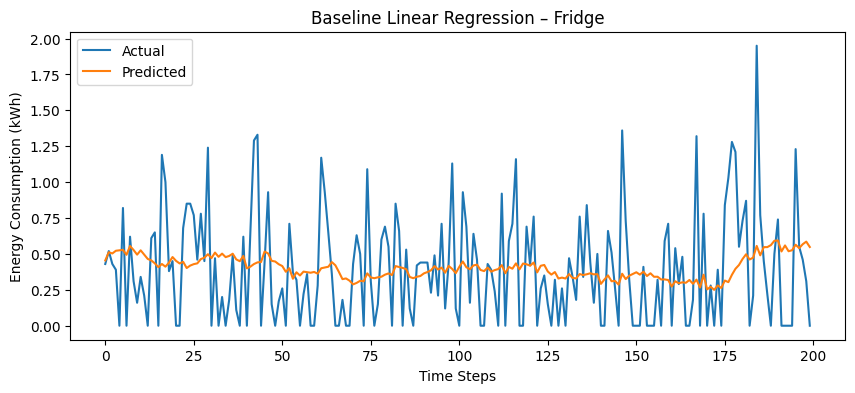


Training model for: Heater


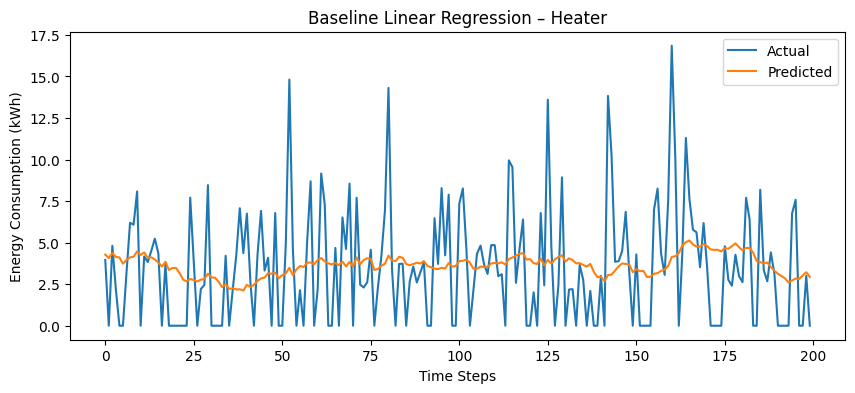


Training model for: Lights


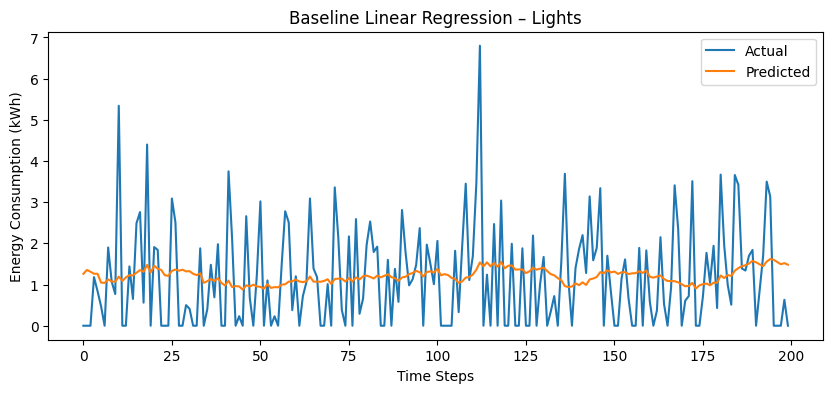


Training model for: Microwave


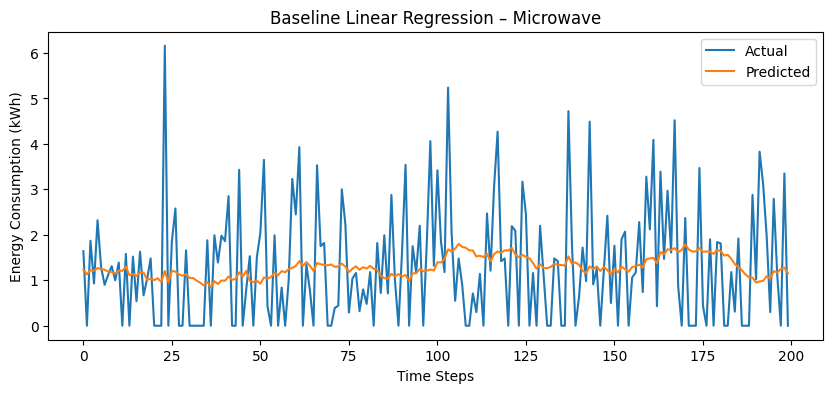


Training model for: Oven


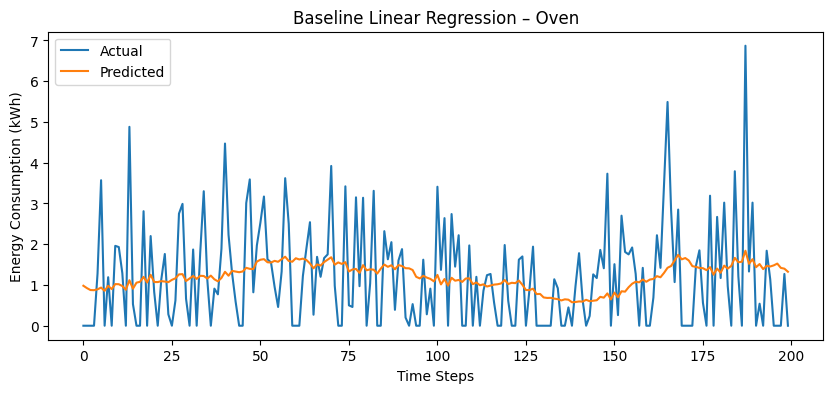


Training model for: TV


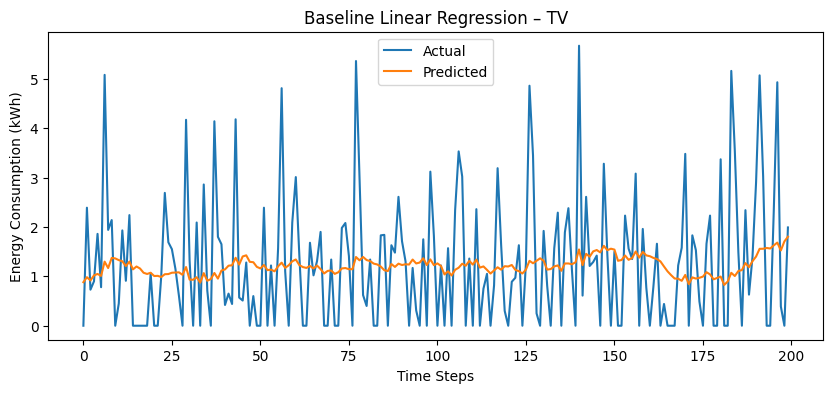


Training model for: Washing Machine


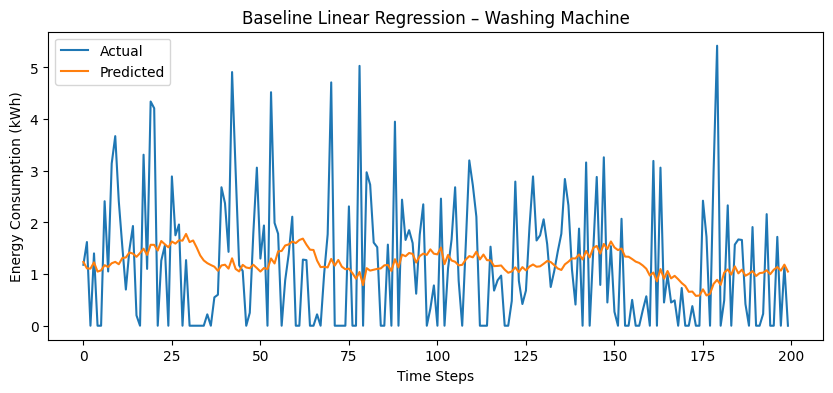

In [12]:
for appliance in appliances:
    print(f"\nTraining model for: {appliance}")

    appliance_df = hourly_df[
        hourly_df["Appliance Type"] == appliance
    ].copy()

    X = appliance_df[FEATURE_COLUMNS]
    y = appliance_df["Energy Consumption (kWh)"]

    # 80–20 time-based split
    split_index = int(len(X) * 0.8)

    X_train = X.iloc[:split_index]
    X_test  = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test  = y.iloc[split_index:]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Appliance": appliance,
        "MAE": mae,
        "RMSE": rmse
    })

    models[appliance] = model

    # REQUIRED PLOT
    plt.figure(figsize=(10,4))
    plt.plot(y_test.values[:200], label="Actual")
    plt.plot(y_pred[:200], label="Predicted")
    plt.title(f"Baseline Linear Regression – {appliance}")
    plt.xlabel("Time Steps")
    plt.ylabel("Energy Consumption (kWh)")
    plt.legend()
    plt.show()

    # Save model
    safe_appliance = appliance.replace(" ", "_")

    joblib.dump(
        model,
        f"../models/linear_regression_{safe_appliance}.pkl"
    )

